In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
from sklearn.feature_extraction.text import CountVectorizer

# Similarity Calculation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

## 📂 Load Dataset

In [4]:
import shutil

shutil.copy("datasets/movies.csv", "movies.csv")
shutil.copy("datasets/ratings.csv", "ratings.csv")

'ratings.csv'

In [5]:
df_movies = pd.read_csv("movies.csv")
df_rating = pd.read_csv("ratings.csv")

In [6]:
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
df_rating.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [8]:
print("Movies Dataset Shape :", df_movies.shape)

Movies Dataset Shape : (62423, 3)


In [9]:
print("Ratings Dataset Shape :", df_rating.shape)

Ratings Dataset Shape : (25000095, 4)


In [10]:
df_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  62423 non-null  int64
 1   title    62423 non-null  str  
 2   genres   62423 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.4 MB


In [11]:
df_rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


In [12]:
df_movies.describe().T

,count,mean,std,min,25%,50%,75%,max
movieId,62423.0,122220.387646,63264.744844,1.0,82146.5,138022.0,173222.0,209171.0


In [13]:
df_rating.describe().T

,count,mean,std,min,25%,50%,75%,max
userId,25000095.0,8.118928e+04,4.679172e+04,1.0,4.051000e+04,8.091400e+04,1.215570e+05,1.625410e+05
movieId,25000095.0,2.138798e+04,3.919886e+04,1.0,1.196000e+03,2.947000e+03,8.623000e+03,2.091710e+05
rating,25000095.0,3.533854e+00,1.060744e+00,0.5,3.000000e+00,3.500000e+00,4.000000e+00,5.000000e+00
timestamp,25000095.0,1.215601e+09,2.268758e+08,789652009.0,1.011747e+09,1.198868e+09,1.447205e+09,1.574328e+09


## 🧹 Data Preprocessing

### 📌 Check Missing Values

In [14]:
# Missing values in Movies Dataset
df_movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [15]:
# Missing values in Ratings Dataset
df_rating.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

### 📌 Check Duplicate Values

In [16]:
# Duplicate values in Movies Dataset
df_movies.duplicated().sum()

np.int64(0)

In [17]:
# Duplicate values in Ratings Dataset
df_rating.duplicated().sum()

np.int64(0)

## 📌 Handle Missing Values

In [18]:
# Fill missing genres with empty string
df_movies['genres'] = df_movies['genres'].fillna('')

In [19]:
# Merge datasets
df = pd.merge(df_rating, df_movies, on='movieId')

# Display merged dataset
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,296,5.0,1147880044,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,1147868817,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,1147868828,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,1,665,5.0,1147878820,Underground (1995),Comedy|Drama|War
4,1,899,3.5,1147868510,Singin' in the Rain (1952),Comedy|Musical|Romance


In [20]:
print("Merged Dataset Shape :", df.shape)

Merged Dataset Shape : (25000095, 6)


In [21]:
df.columns

Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='str')

## 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to understand the dataset through statistics and visualizations. 

* Popular movies
* Rating patterns
* Genre distribution
* User activity
* Trends in the dataset

EDA is an important step before building the recommendation system

## 🎥 Top Rated Movies

In [22]:
# Average rating of each movie
top_rated = df.groupby('title')['rating'].mean().sort_values(ascending=False)

# Convert into dataframe
top_rated = pd.DataFrame(top_rated)

# Display top 10 rated movies
top_rated.head(10)

,rating
title,
Iran Is Not the Problem (2008),5.0
.hack Liminality In the Case of Yuki Aihara,5.0
$uperthief: Inside America's Biggest Bank Score (2012),5.0
.hack Liminality In the Case of Kyoko Tohno,5.0
...E fuori nevica! (2014),5.0
The Girl from Flanders (1956),5.0
'Master Harold' ... And the Boys (2010),5.0
Isabelle Dances Into the Spotlight (2014),5.0
"Love, Cheat & Steal (1993)",5.0


## ⭐ Most Popular Movies

In [23]:
# Count ratings for each movie
popular_movies = df.groupby('title')['rating'].count().sort_values(ascending=False)

# Convert into dataframe
popular_movies = pd.DataFrame(popular_movies)

# Display top 10 popular movies
popular_movies.head(10)

,rating
title,
Forrest Gump (1994),81491
"Shawshank Redemption, The (1994)",81482
Pulp Fiction (1994),79672
"Silence of the Lambs, The (1991)",74127
"Matrix, The (1999)",72674
Star Wars: Episode IV - A New Hope (1977),68717
Jurassic Park (1993),64144
Schindler's List (1993),60411
Braveheart (1995),59184


## 📈 Rating Distribution

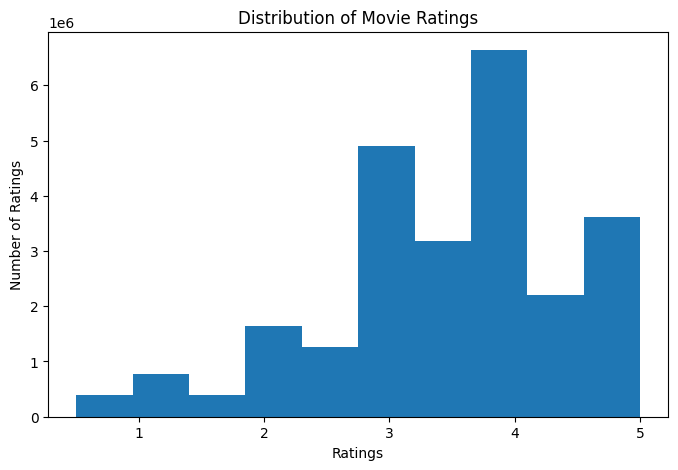

In [24]:
plt.figure(figsize=(8,5))

plt.hist(df['rating'])

plt.xlabel("Ratings")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")

plt.show()

## 🎭 Genre Analysis

In [25]:
# Split genres
genres = df_movies['genres'].str.split('|').explode()

# Count genres
genre_count = genres.value_counts()

# Display genre counts
genre_count

genres
Drama                 25606
Comedy                16870
Thriller               8654
Romance                7719
Action                 7348
Horror                 5989
Documentary            5605
Crime                  5319
(no genres listed)     5062
Adventure              4145
Sci-Fi                 3595
Children               2935
Animation              2929
Mystery                2925
Fantasy                2731
War                    1874
Western                1399
Musical                1054
Film-Noir               353
IMAX                    195
Name: count, dtype: int64

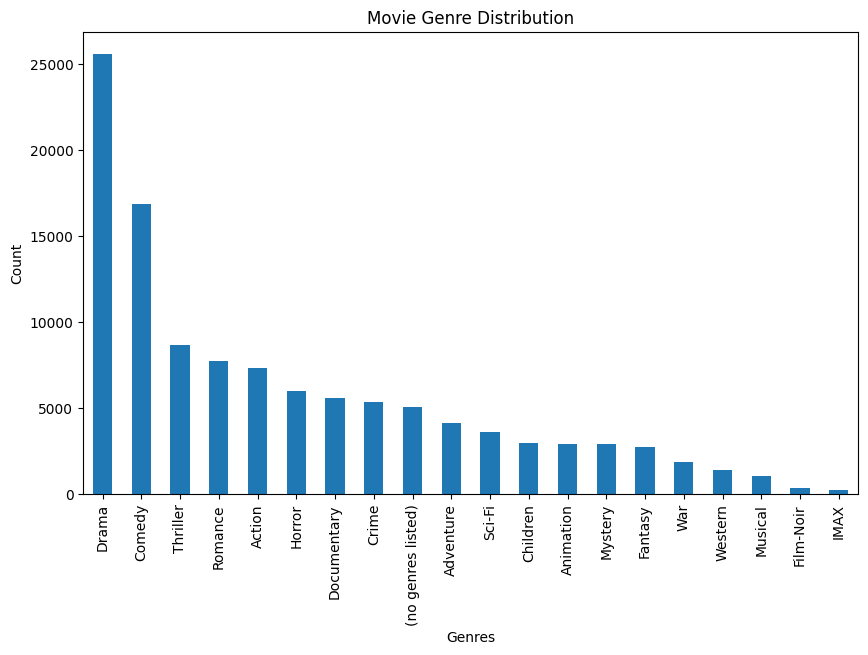

In [26]:
plt.figure(figsize=(10,6))

genre_count.plot(kind='bar')

plt.xlabel("Genres")
plt.ylabel("Count")
plt.title("Movie Genre Distribution")

plt.show()

👤 Most Active Users

In [27]:
# Extract year
df_movies['year'] = df_movies['title'].str.extract(r'\((\d{4})\)')

# Display first rows
df_movies.head()

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


🎬 Movies Released Per Year

In [28]:
# Extract year
df_movies['year'] = df_movies['title'].str.extract(r'\((\d{4})\)')

# Display first rows
df_movies.head()

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


📉 Movies Released Trend

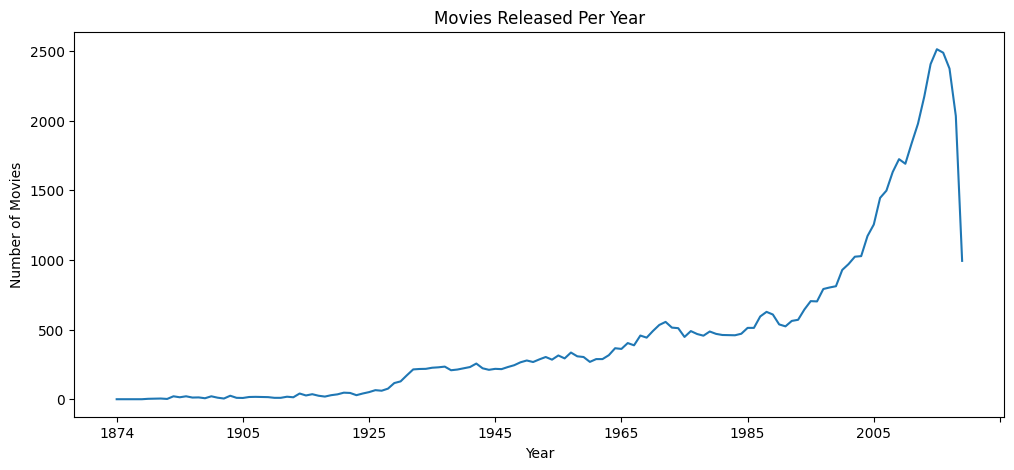

In [29]:

movies_per_year = df_movies['year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

movies_per_year.plot()

plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released Per Year")

plt.show()


## 🤖 Building the Movie Recommendation System

In [30]:
movies_data = df_movies[['movieId', 'title', 'genres']]

movies_data.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [31]:
movies_data['genres'] = movies_data['genres'].fillna('')

In [32]:
# Initialize CountVectorizer
cv = CountVectorizer(tokenizer=lambda x: x.split('|'))

# Convert genres into matrix
count_matrix = cv.fit_transform(movies_data['genres'])

print(count_matrix)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 112307 stored elements and shape (62423, 20)>
  Coords	Values
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 9)	1
  (1, 2)	1
  (1, 4)	1
  (1, 9)	1
  (2, 5)	1
  (2, 15)	1
  (3, 5)	1
  (3, 15)	1
  (3, 8)	1
  (4, 5)	1
  (5, 1)	1
  (5, 6)	1
  (5, 17)	1
  (6, 5)	1
  (6, 15)	1
  (7, 2)	1
  (7, 4)	1
  (8, 1)	1
  (9, 2)	1
  (9, 1)	1
  (9, 17)	1
  :	:
  (62407, 0)	1
  (62408, 9)	1
  (62408, 7)	1
  (62409, 19)	1
  (62410, 8)	1
  (62411, 5)	1
  (62412, 3)	1
  (62412, 7)	1
  (62413, 8)	1
  (62414, 6)	1
  (62414, 11)	1
  (62415, 0)	1
  (62416, 5)	1
  (62416, 8)	1
  (62417, 5)	1
  (62417, 15)	1
  (62417, 1)	1
  (62418, 8)	1
  (62419, 7)	1
  (62420, 5)	1
  (62420, 8)	1
  (62421, 0)	1
  (62422, 2)	1
  (62422, 8)	1
  (62422, 1)	1


In [33]:
print(count_matrix.shape)

(62423, 20)


In [34]:
tfidf = TfidfVectorizer(token_pattern=r'[^|]+')

tfidf_matrix = tfidf.fit_transform(df_movies['genres'])


In [35]:
model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

model.fit(tfidf_matrix)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [36]:
def recommend(movie_name):

    movie_name = movie_name.lower()

    # Find movie index
    idx = df_movies[
        df_movies['title'].str.lower() == movie_name
    ].index

    if len(idx) == 0:
        print("Movie not found!")
        return

    idx = idx[0]

    # Find nearest neighbors
    distances, indices = model.kneighbors(
        tfidf_matrix[idx],
        n_neighbors=11
    )

    print(f"\n🎬 Recommended Movies for '{df_movies.iloc[idx]['title']}'\n")

    for i in range(1, len(indices[0])):

        movie_idx = indices[0][i]

        print(df_movies.iloc[movie_idx]['title'])

In [37]:
recommend("Toy Story (1995)")


🎬 Recommended Movies for 'Toy Story (1995)'

The Magic Crystal (2011)
Monsters, Inc. (2001)
Adventures of Rocky and Bullwinkle, The (2000)
Asterix and the Vikings (Astérix et les Vikings) (2006)
Missing Link (2019)
Antz (1998)
Aladdin (1992)
Boxtrolls, The (2014)
Here Comes the Grump (2018)
Trolls Holiday (2017)


In [38]:
recommend("Jumanji (1995)")


🎬 Recommended Movies for 'Jumanji (1995)'

Jumanji (1995)
Old Man Khottabych (1956)
Alice Through the Looking Glass (2016)
The Snow Queen (1966)
Red Riding Hood (1989)
Brothers Lionheart, The (Bröderna Lejonhjärta) (1977)
NeverEnding Story III, The (1994)
Darby O'Gill and the Little People (1959)
Ruslan and Ludmila (1972)
Santa Claus: The Movie (1985)


In [39]:
recommend("Heat (1995)")


🎬 Recommended Movies for 'Heat (1995)'

Pickings (2018)
Lucky Day (2019)
Deadbeat at Dawn (1988)
Dangerous Encounters of the First Kind (1980)
Dead or Alive 2: Tôbôsha (2000)
Accident Man (2018)
The Pyramid (2007)
Angel (1984)
U.S. Marshals (1998)
In the Blood (2014)


In [40]:
recommend("ABC Movie")

Movie not found!


In [44]:
recommend("Ace Ventura: When Nature Calls (1995)")


🎬 Recommended Movies for 'Ace Ventura: When Nature Calls (1995)'

Seth Meyers: Lobby Baby (2019)
Strange Bedfellows (2004)
Achilles and the Tortoise (Akiresu to kame) (2008)
Медведь (1938)
The Straw Hat (1974)
The Dog in the Manger (1977)
The Actors (2003)
Empties (2007)
Goon: Last of the Enforcers (2017)
BoJack Horseman Christmas Special: Sabrina's Christmas Wish (2014)


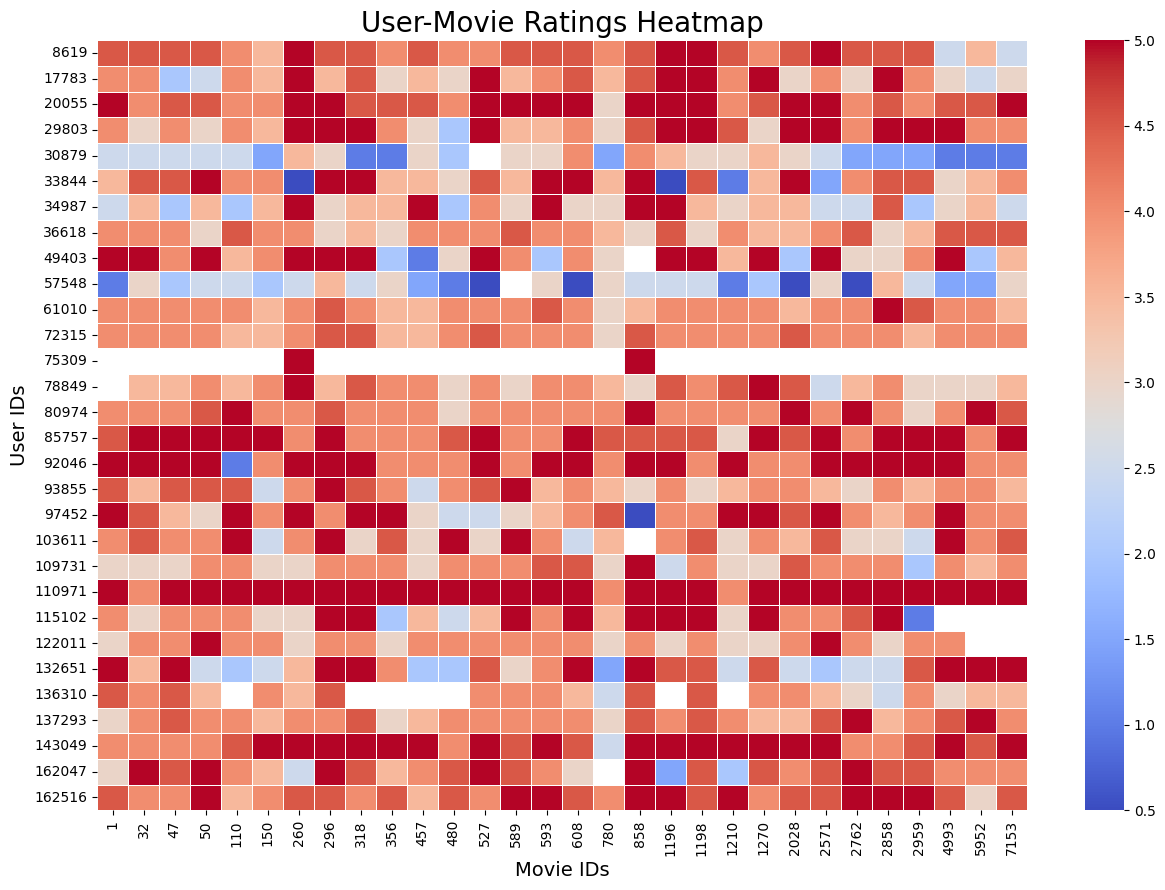

In [42]:
# ==========================================
# USER-MOVIE RATINGS HEATMAP
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reload data after kernel restart
df_rating = pd.read_csv("ratings.csv", dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})

# Filter to top 30 users and top 30 movies BEFORE pivot
top_movies = df_rating['movieId'].value_counts().head(30).index
top_users  = df_rating['userId'].value_counts().head(30).index

filtered = df_rating[
    df_rating['movieId'].isin(top_movies) &
    df_rating['userId'].isin(top_users)
]

# Create User-Movie Matrix
movie_matrix = filtered.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

# Select smaller portion for visualization
heatmap_data = movie_matrix.iloc[:30, :30]

# Create Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar=True
)

# Titles and Labels
plt.title("User-Movie Ratings Heatmap", fontsize=20)
plt.xlabel("Movie IDs", fontsize=14)
plt.ylabel("User IDs", fontsize=14)

plt.show()